In [108]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# !pip3 install numpy==1.26.4

In [109]:
import pysindy as ps
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error


In [110]:
# !pip3 install numpy==1.26.4

In [111]:
df0 = pd.read_csv(r'/Users/lolovolkova/Desktop/pressure.txt', delimiter = "\s+", index_col=False, header=None)

df1 = pd.read_csv(r'/Users/lolovolkova/Desktop/velocity.txt', delimiter = "\s+", index_col=False, header=None)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/var/folders/7t/30q04zg93ml866ymrq48nkk80000gn/T/ipykernel_85641/3592897361.py:1: SyntaxWarning: invalid escape sequence '\s'
  df0 = pd.read_csv(r'/Users/lolovolkova/Desktop/pressure.txt', delimiter = "\s+", index_col=False, header=None)
/var/folders/7t/30q04zg93ml866ymrq48nkk80000gn/T/ipykernel_85641/3592897361.py:3: SyntaxWarning: invalid escape sequence '\s'
  df1 = pd.read_csv(r'/Users/lolovolkova/Desktop/velocity.txt', delimiter = "\s+", index_col=False, header=None)


In [112]:
df1

,0,1,2,3,4,5,6,7,8,9,...,4992,4993,4994,4995,4996,4997,4998,4999,5000,5001
0,-10.00,0.0,-0.011573,-0.010220,-0.009467,-0.008559,-0.007536,-0.006433,-0.005282,-0.004116,...,0.000057,0.000058,0.000059,0.000060,0.000060,0.000061,0.000062,0.000062,0.000063,0.000064
1,-9.98,0.0,-0.014265,-0.012772,-0.011815,-0.010669,-0.009381,-0.007995,-0.006552,-0.005092,...,0.000071,0.000072,0.000073,0.000074,0.000075,0.000076,0.000077,0.000078,0.000079,0.000080
2,-9.96,0.0,-0.021939,-0.020477,-0.018894,-0.017060,-0.014997,-0.012777,-0.010467,-0.008130,...,0.000114,0.000116,0.000118,0.000119,0.000121,0.000122,0.000124,0.000125,0.000126,0.000128
3,-9.94,0.0,-0.031103,-0.030784,-0.028361,-0.025624,-0.022542,-0.019221,-0.015761,-0.012260,...,0.000171,0.000174,0.000176,0.000179,0.000181,0.000183,0.000185,0.000187,0.000189,0.000191
4,-9.92,0.0,-0.038433,-0.041022,-0.037840,-0.034198,-0.030098,-0.025677,-0.021069,-0.016402,...,0.000228,0.000232,0.000235,0.000238,0.000241,0.000244,0.000247,0.000250,0.000253,0.000255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,9.92,0.0,-0.041035,-0.046025,-0.045624,-0.044448,-0.042721,-0.040494,-0.037800,-0.034640,...,-0.000280,-0.000278,-0.000276,-0.000274,-0.000272,-0.000270,-0.000267,-0.000265,-0.000262,-0.000260
997,9.94,0.0,-0.032386,-0.034613,-0.034237,-0.033357,-0.032064,-0.030397,-0.028379,-0.026013,...,-0.000210,-0.000209,-0.000207,-0.000206,-0.000204,-0.000202,-0.000200,-0.000199,-0.000197,-0.000195
998,9.96,0.0,-0.022326,-0.023105,-0.022834,-0.022248,-0.021387,-0.020277,-0.018933,-0.017357,...,-0.000140,-0.000139,-0.000138,-0.000137,-0.000136,-0.000135,-0.000134,-0.000132,-0.000131,-0.000130
999,9.98,0.0,-0.011366,-0.011559,-0.011419,-0.011127,-0.010697,-0.010142,-0.009471,-0.008683,...,-0.000070,-0.000070,-0.000069,-0.000068,-0.000068,-0.000067,-0.000067,-0.000066,-0.000066,-0.000065


In [113]:
pressure = df0.drop(df0.columns[[0]], axis=1).to_numpy()

x = df0.iloc[:,0].to_numpy()

u = df1.drop(df1.columns[[0]], axis=1).to_numpy()

#t = df00.iloc[0,:].to_numpy()

totalNt = (df0.shape[1] - 1)
t1 = np.linspace(0,totalNt-1,totalNt)
t = t1/10


L = 20 # Lenght of 1D system
N = len(x) # Number of spatial points 

T = t[-1] # Total time
Nt = len(t) # Number of temporal points

In [114]:
data = np.zeros((N, Nt, 2))

data[:,:,0] = u
data[:,:,1] = pressure


In [115]:
data[:,:,1].shape

(1001, 5001)

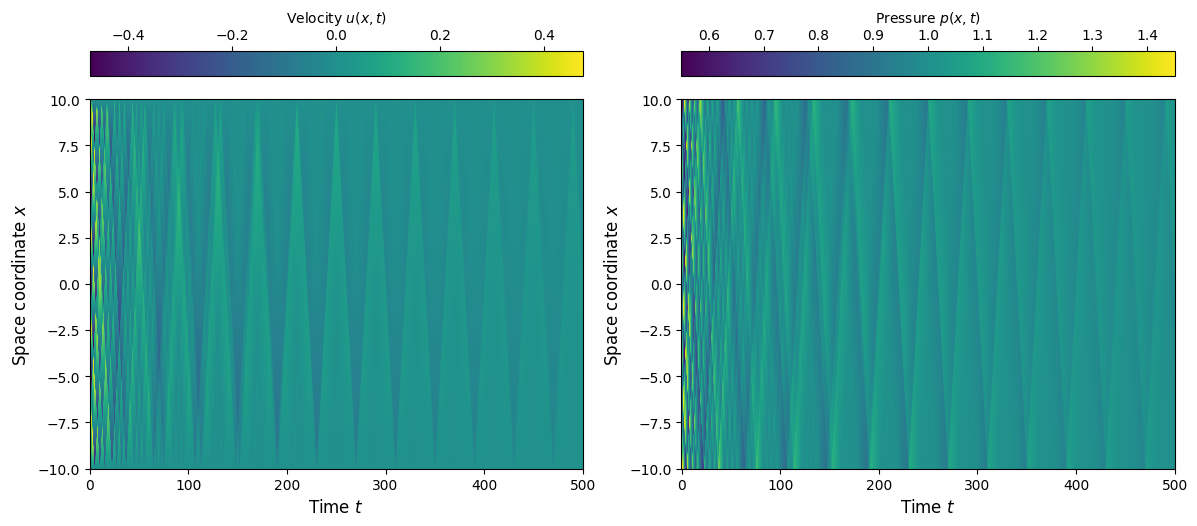

In [116]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.pcolormesh(t, x, data[:, :, 0])
plt.colorbar(label = 'Velocity $u(x,t)$', orientation = 'horizontal', location = 'top')
plt.xlabel('Time $t$', fontsize=12)
plt.ylabel('Space coordinate $x$', fontsize=12)
#plt.title(r'$u$', fontsize=16)

plt.subplot(1, 2, 2)
plt.pcolormesh(t, x, data[:, :, 1])
plt.colorbar(label = 'Pressure $p(x,t)$', orientation = 'horizontal', location = 'top')
plt.xlabel('Time $t$', fontsize=12)
plt.ylabel('Space coordinate $x$', fontsize=12)
#plt.title(r'$\rho$', fontsize=16)

plt.show()


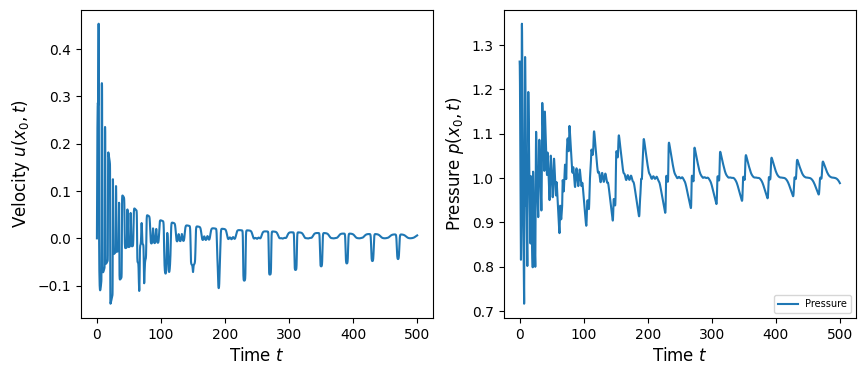

In [117]:
x_location = 100

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(t, data[x_location, :, 0],'-', color = 'C0', label='Velocity')
plt.xlabel('Time $t$', fontsize=12)
plt.ylabel('Velocity $u(x_0,t)$', fontsize=12)
#plt.legend(loc = 1, fontsize = 7)
#plt.title('u', fontsize=16)

plt.subplot(1, 2, 2)
plt.plot(t, data[x_location, :, 1],'-',color = 'C0',label='Pressure')
plt.xlabel('Time $t$', fontsize=12)
plt.ylabel(r'Pressure $p(x_0,t)$', fontsize=12)
plt.legend(loc = 4, fontsize = 7)
#plt.yticks(np.arange(0.9, 1.09, 0.05))
#plt.title(r'$\rho$', fontsize=16)

plt.show()


Text(0.5, 0.92, 'Velocity evolution in space and time')

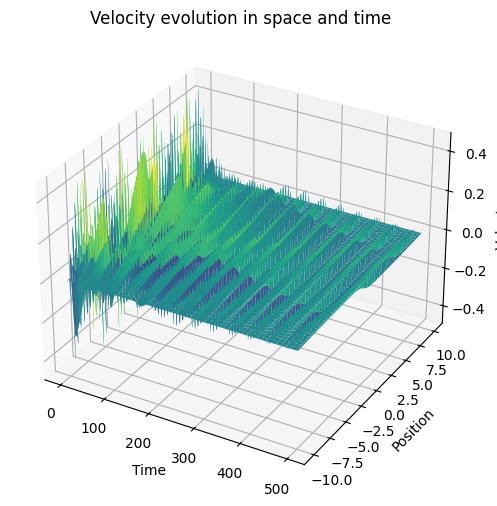

In [118]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')
T, X = np.meshgrid(t, x)
ax.plot_surface(T, X, data[:,:,0], cmap='viridis')
ax.set_xlabel('Time')
ax.set_ylabel('Position')
ax.set_zlabel('Velocity')
plt.title('Velocity evolution in space and time')

Text(0.5, 0.92, 'Pressure evolution in space and time')

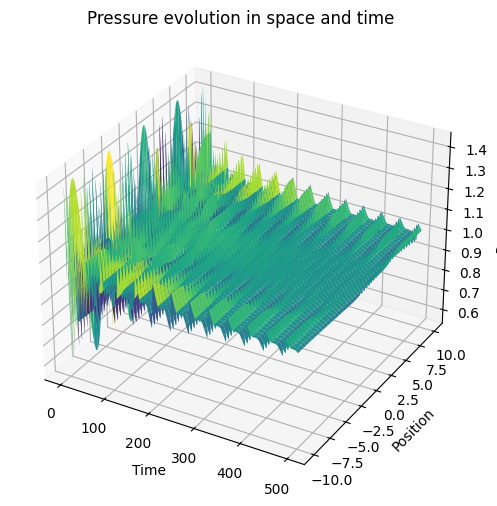

In [119]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')
T, X = np.meshgrid(t, x)
ax.plot_surface(T, X, data[:,:,1], cmap='viridis')
ax.set_xlabel('Time')
ax.set_ylabel('Position')
ax.set_zlabel('Pressure')
plt.title('Pressure evolution in space and time')

Simple SINDY 

(x0)' = 0.171 1 + 0.331 x0 + -0.171 x1 + -0.290 x0^2 x1 + -0.327 x0 x1^2
(x1)' = -0.631 x0 + 5.645 x0^3 + -1.683 x0^2 x1 + 0.777 x0 x1^2


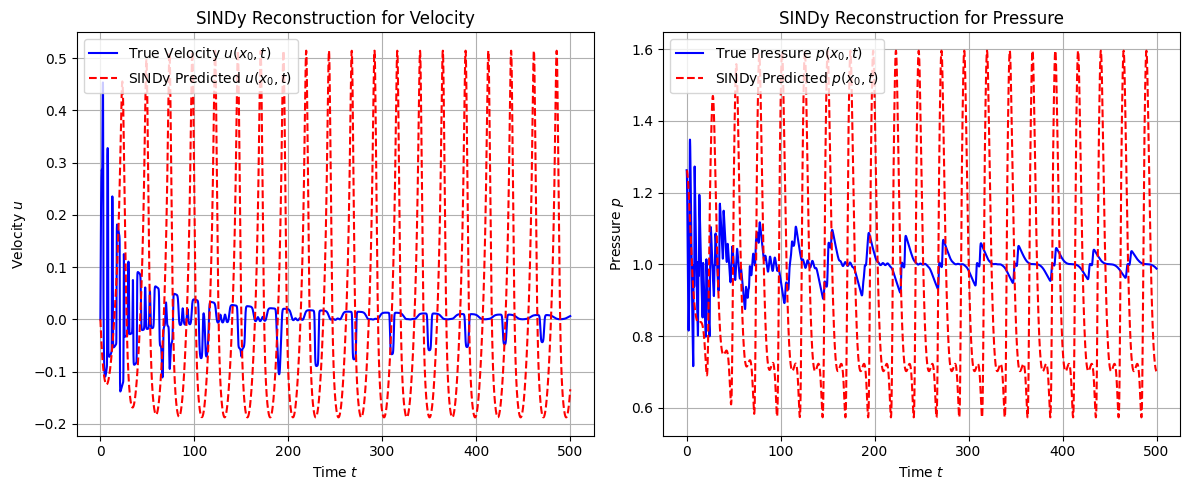

In [65]:
x_location = 100
u_data = data[x_location, :, 0].reshape(-1, 1)  # velocity (Nt, 1)
p_data = data[x_location, :, 1].reshape(-1, 1)  # pressure (Nt, 1)

X = np.hstack([u_data, p_data])  # (Nt, 2)
dt = t[1] - t[0]

poly_library = ps.PolynomialLibrary(degree=3)
diff_method = ps.FiniteDifference()
optimizer = ps.STLSQ(threshold=0.1)

model = ps.SINDy(
    feature_library=poly_library,
    optimizer=optimizer,
    differentiation_method=diff_method
)

# Fit the SINDy model
model.fit(X, t=dt)
model.print()

# Predict trajectory using SINDy
X0 = X[0]  # initial condition
X_pred = model.simulate(X0, t)

# Plot the reconstruction for both velocity and pressure
plt.figure(figsize=(12, 5))

# Velocity plot
plt.subplot(1, 2, 1)
plt.plot(t, X[:, 0], 'b', label='True Velocity $u(x_0,t)$')
plt.plot(t, X_pred[:, 0], 'r--', label='SINDy Predicted $u(x_0,t)$')
plt.xlabel('Time $t$')
plt.ylabel('Velocity $u$')
plt.legend()
plt.grid(True)
plt.title(f'SINDy Reconstruction for Velocity')

# Pressure plot
plt.subplot(1, 2, 2)
plt.plot(t, X[:, 1], 'b', label='True Pressure $p(x_0,t)$')
plt.plot(t, X_pred[:, 1], 'r--', label='SINDy Predicted $p(x_0,t)$')
plt.xlabel('Time $t$')
plt.ylabel('Pressure $p$')
plt.legend()
plt.grid(True)
plt.title(f'SINDy Reconstruction for Pressure')

plt.tight_layout()
plt.show()

Damped oscillator

<>:43: SyntaxWarning: invalid escape sequence '\d'
<>:44: SyntaxWarning: invalid escape sequence '\d'
<>:46: SyntaxWarning: invalid escape sequence '\d'
<>:43: SyntaxWarning: invalid escape sequence '\d'
<>:44: SyntaxWarning: invalid escape sequence '\d'
<>:46: SyntaxWarning: invalid escape sequence '\d'
/var/folders/7t/30q04zg93ml866ymrq48nkk80000gn/T/ipykernel_85641/3760440099.py:43: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(t, du, label='True $\dot{u}(t)$', color='blue')
/var/folders/7t/30q04zg93ml866ymrq48nkk80000gn/T/ipykernel_85641/3760440099.py:44: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(t, X_sim[:, 1], '--', label='SINDy $\dot{u}(t)$', color='red')
/var/folders/7t/30q04zg93ml866ymrq48nkk80000gn/T/ipykernel_85641/3760440099.py:46: SyntaxWarning: invalid escape sequence '\d'
  plt.ylabel('Velocity derivative $\dot{u}$')


Discovered equations for velocity (damped oscillator form):
(x0)' = 1.000 x1
(x1)' = 0.003 1 + -2.440 x0 + -0.027 x1


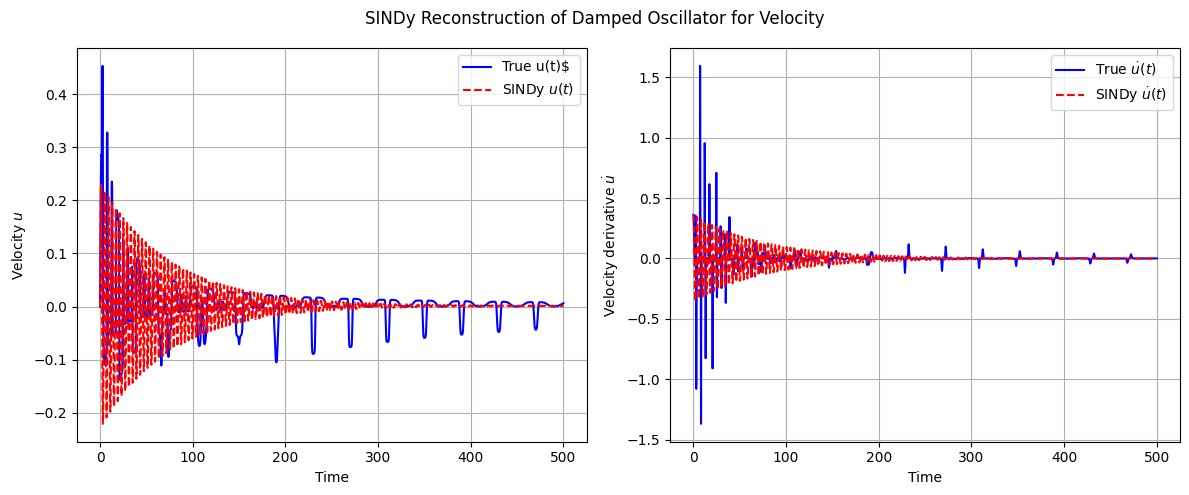

In [85]:
x_location = 100

# Extract pressure p at chosen spatial location
u = data[x_location, :, 0]
dt = t[1] - t[0]

# Compute derivatives
du = np.gradient(u, dt)
ddu = np.gradient(du, dt)

# State vector: [u, du/dt]
X_u = np.vstack([u, du]).T

# Time derivatives of the states: [dp/dt, ddp/dt]
dX_dt = np.vstack([du, ddu]).T

# Use linear library (degree=1) to capture damped oscillator structure
library = ps.PolynomialLibrary(degree=1)
optimizer = ps.STLSQ(threshold=1e-3)  # threshold can be adjusted
model = ps.SINDy(feature_library=library, optimizer=optimizer)

# Fit the model
model.fit(X_u, t=dt, x_dot=dX_dt)
print("Discovered equations for velocity (damped oscillator form):")
model.print()

# Simulate the learned model from initial condition
X0 = X_u[0]
X_sim = model.simulate(X0, t)

# Plot the reconstruction
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t, u, label='True u(t)$', color='blue')
plt.plot(t, X_sim[:, 0], '--', label='SINDy $u(t)$', color='red')
plt.xlabel('Time')
plt.ylabel('Velocity $u$')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(t, du, label='True $\dot{u}(t)$', color='blue')
plt.plot(t, X_sim[:, 1], '--', label='SINDy $\dot{u}(t)$', color='red')
plt.xlabel('Time')
plt.ylabel('Velocity derivative $\dot{u}$')
plt.legend()
plt.grid()

plt.suptitle(f'SINDy Reconstruction of Damped Oscillator for Velocity')
plt.tight_layout()
plt.show()

<>:42: SyntaxWarning: invalid escape sequence '\d'
<>:43: SyntaxWarning: invalid escape sequence '\d'
<>:45: SyntaxWarning: invalid escape sequence '\d'
<>:42: SyntaxWarning: invalid escape sequence '\d'
<>:43: SyntaxWarning: invalid escape sequence '\d'
<>:45: SyntaxWarning: invalid escape sequence '\d'
/var/folders/7t/30q04zg93ml866ymrq48nkk80000gn/T/ipykernel_85641/787928897.py:42: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(t, dp, label='True $\dot{p}(t)$', color='blue')
/var/folders/7t/30q04zg93ml866ymrq48nkk80000gn/T/ipykernel_85641/787928897.py:43: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(t, X_sim[:, 1], '--', label='SINDy $\dot{p}(t)$', color='red')
/var/folders/7t/30q04zg93ml866ymrq48nkk80000gn/T/ipykernel_85641/787928897.py:45: SyntaxWarning: invalid escape sequence '\d'
  plt.ylabel('Pressure derivative $\dot{p}$')


Discovered equations for pressure (damped oscillator form):
(x0)' = 1.000 x1
(x1)' = 1.753 1 + -1.753 x0 + -0.029 x1


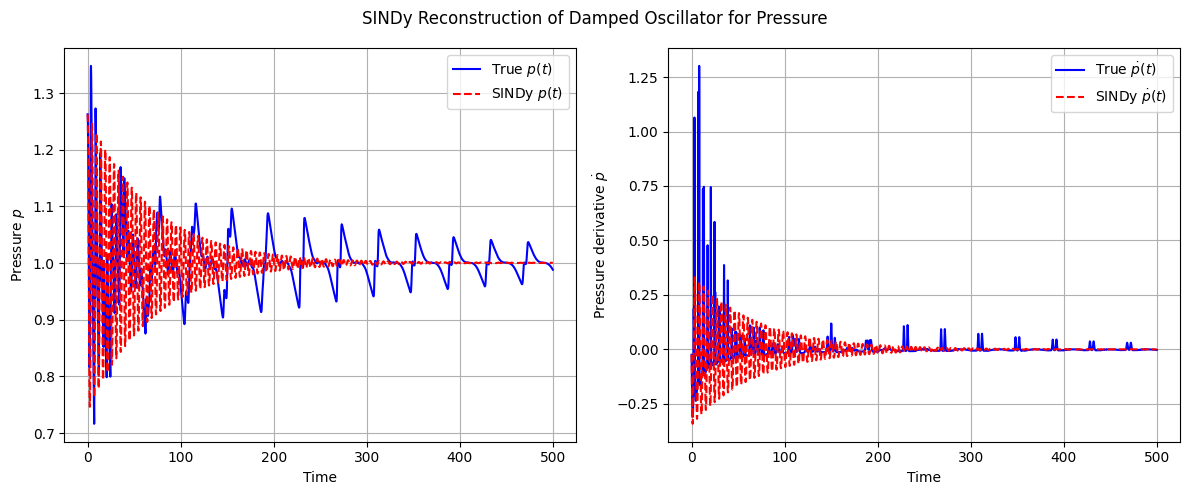

In [73]:
x_location = 100
# Extract pressure p at chosen spatial location
p = data[x_location, :, 1]
dt = t[1] - t[0]

# Compute derivatives
dp = np.gradient(p, dt)
ddp = np.gradient(dp, dt)

# State vector: [p, dp/dt]
X = np.vstack([p, dp]).T

# Time derivatives of the states: [dp/dt, ddp/dt]
dX_dt = np.vstack([dp, ddp]).T

# Use linear library (degree=1) to capture damped oscillator structure
library = ps.PolynomialLibrary(degree=1)
optimizer = ps.STLSQ(threshold=1e-3)  # threshold can be adjusted
model = ps.SINDy(feature_library=library, optimizer=optimizer)

# Fit the model
model.fit(X, t=dt, x_dot=dX_dt)
print("Discovered equations for pressure (damped oscillator form):")
model.print()

# Simulate the learned model from initial condition
X0 = X[0]
X_sim = model.simulate(X0, t)

# Plot the reconstruction
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t, p, label='True $p(t)$', color='blue')
plt.plot(t, X_sim[:, 0], '--', label='SINDy $p(t)$', color='red')
plt.xlabel('Time')
plt.ylabel('Pressure $p$')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(t, dp, label='True $\dot{p}(t)$', color='blue')
plt.plot(t, X_sim[:, 1], '--', label='SINDy $\dot{p}(t)$', color='red')
plt.xlabel('Time')
plt.ylabel('Pressure derivative $\dot{p}$')
plt.legend()
plt.grid()

plt.suptitle(f'SINDy Reconstruction of Damped Oscillator for Pressure')
plt.tight_layout()
plt.show()

SINDY with pre-processing

In [120]:
import time

In [121]:
x_loc = 100

# Extract time series at this spatial point
u_data = data[x_loc, :, 0].reshape(-1, 1)  # velocity
p_data = data[x_loc, :, 1].reshape(-1, 1)  # pressure
dt = t[1] - t[0]

In [122]:
from scipy.signal import savgol_filter
# Smooth the velocity data and compute time derivative
window_length = 51  # must be odd and < len(u_data)
polyorder = 3

# Filtered velocity
u_smooth = savgol_filter(u_data.flatten(), window_length=window_length, polyorder=polyorder)

# Derivative of velocity
du_dt = savgol_filter(u_data.flatten(), window_length=window_length, polyorder=polyorder, deriv=1, delta=dt)

# Reshape
u_smooth = u_smooth.reshape(-1, 1)
du_dt = du_dt.reshape(-1, 1)

In [123]:
# Initialize model

optimizer = ps.STLSQ(threshold=1e-10, alpha=1e-10, fit_intercept=False)
library = ps.PolynomialLibrary(degree=3, include_interaction=True, include_bias=True)
model = ps.SINDy(optimizer=optimizer, feature_library=library)

# Fit model with known derivative
start = time.time()
model.fit(x=u_smooth, u=p_data, t=dt, x_dot=du_dt)
train_time = time.time() - start

# Predict using same input
start = time.time()
u_pred = model.predict(x=u_smooth, u=p_data)
pred_time = time.time() - start

SINDy MAE: 0.024407
Train time: 0.0063s, Predict time: 0.0013s


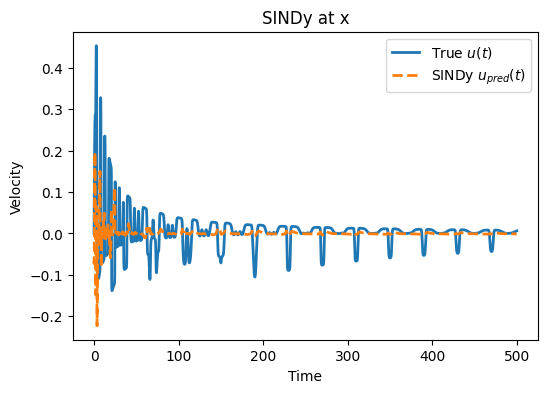

(x0)' = 8.527 1 + -9.220 x0 + -24.867 u0 + -8.484 x0^2 + 16.674 x0 u0 + 24.112 u0^2 + 4.642 x0^3 + 8.306 x0^2 u0 + -7.467 x0 u0^2 + -7.772 u0^3


In [125]:
mae = mean_absolute_error(u_data, u_pred)

print(f"SINDy MAE: {mae:.6f}")
print(f"Train time: {train_time:.4f}s, Predict time: {pred_time:.4f}s")

plt.figure(figsize=(6, 4))
plt.plot(t, u_data, label='True $u(t)$', linewidth=2)
plt.plot(t, u_pred, '--', label='SINDy $u_{pred}(t)$', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Velocity')
plt.title(f'SINDy at x')
plt.legend()
plt.show()

model.print()

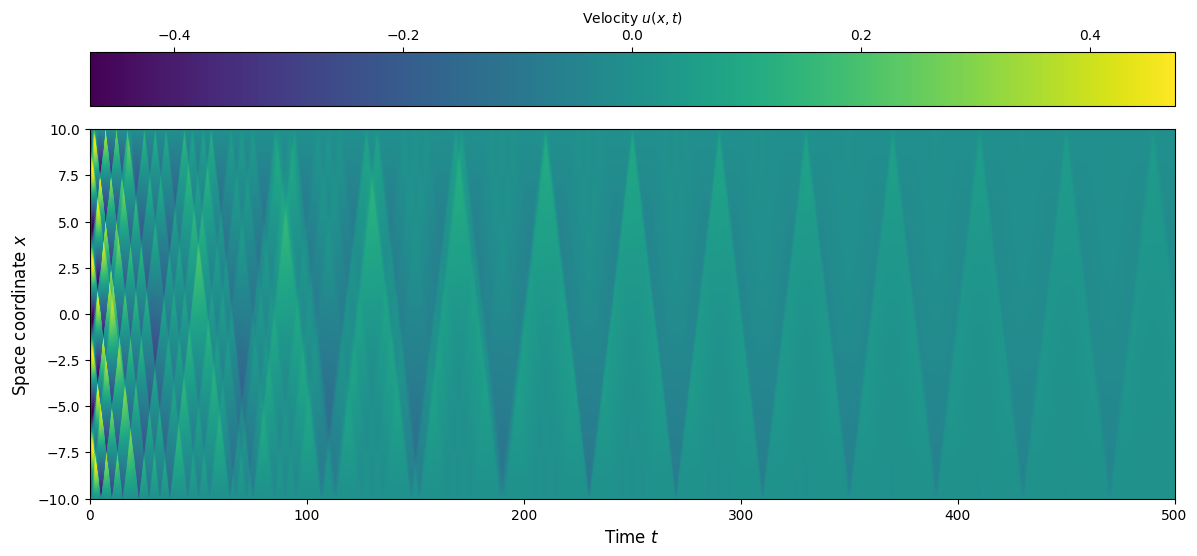

In [91]:
plt.figure(figsize=(14, 6))
# plt.subplot(1, 2, 1)
plt.pcolormesh(t, x, data[:, :, 0])
plt.colorbar(label = 'Velocity $u(x,t)$', orientation = 'horizontal', location = 'top')
plt.xlabel('Time $t$', fontsize=12)
plt.ylabel('Space coordinate $x$', fontsize=12)
#plt.title(r'$u$', fontsize=16)

# plt.subplot(1, 2, 2)
# plt.pcolormesh(t, x, data[:, :, 1])
# plt.colorbar(label = 'Pressure $p(x,t)$', orientation = 'horizontal', location = 'top')
# plt.xlabel('Time $t$', fontsize=12)
# plt.ylabel('Space coordinate $x$', fontsize=12)
# #plt.title(r'$\rho$', fontsize=16)

plt.show()


In [92]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import time

# Setup
N, Nt = data.shape[0], data.shape[1]
dt = t[1] - t[0]

# Storage
u_pred_full = np.zeros((N, Nt))
train_times = []
pred_times = []

# SINDy config
optimizer = ps.STLSQ(threshold=1e-5, alpha=1e-4, fit_intercept=False)
library = ps.PolynomialLibrary(degree=3, include_interaction=True)
model = ps.SINDy(optimizer=optimizer, feature_library=library, feature_names=["u", "p"])

# Loop over space
for i in range(N):
    u_data = data[i, :, 0].reshape(-1, 1)
    p_data = data[i, :, 1].reshape(-1, 1)

    # Smooth + differentiate
    u_smooth = savgol_filter(u_data.flatten(), window_length=51, polyorder=3)
    du_dt = savgol_filter(u_data.flatten(), window_length=51, polyorder=3, deriv=1, delta=dt)
    u_smooth = u_smooth.reshape(-1, 1)
    du_dt = du_dt.reshape(-1, 1)

    # Train model
    start_train = time.time()
    model.fit(x=u_smooth, u=p_data, x_dot=du_dt, t=dt)
    train_times.append(time.time() - start_train)

    # Predict
    start_pred = time.time()
    u_pred = model.predict(x=u_smooth, u=p_data)
    pred_times.append(time.time() - start_pred)

    u_pred_full[i, :] = u_pred.flatten()

<>:13: SyntaxWarning: invalid escape sequence '\h'
<>:13: SyntaxWarning: invalid escape sequence '\h'
/var/folders/7t/30q04zg93ml866ymrq48nkk80000gn/T/ipykernel_85641/4173907481.py:13: SyntaxWarning: invalid escape sequence '\h'
  plt.colorbar(label='Predicted Velocity $\hat{u}(x,t)$', orientation='horizontal', location='top')


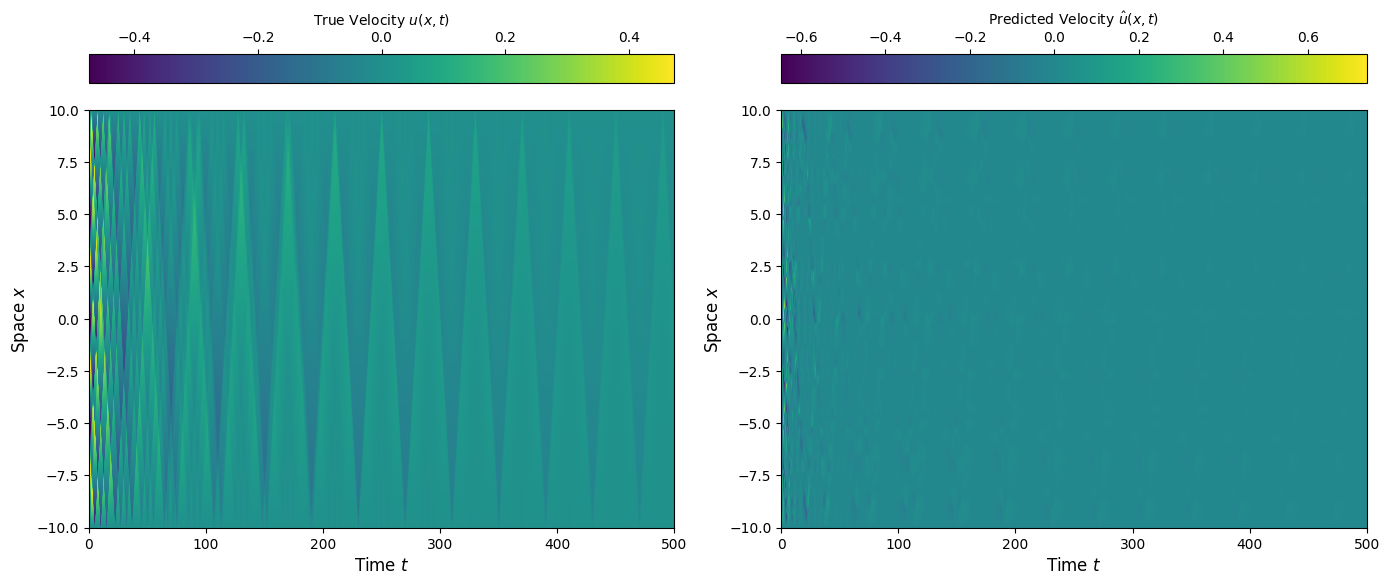

In [93]:
plt.figure(figsize=(14, 6))

# True velocity
plt.subplot(1, 2, 1)
plt.pcolormesh(t, x, data[:, :, 0], shading='auto')
plt.colorbar(label='True Velocity $u(x,t)$', orientation='horizontal', location='top')
plt.xlabel('Time $t$', fontsize=12)
plt.ylabel('Space $x$', fontsize=12)

# Predicted velocity
plt.subplot(1, 2, 2)
plt.pcolormesh(t, x, u_pred_full, shading='auto')
plt.colorbar(label='Predicted Velocity $\hat{u}(x,t)$', orientation='horizontal', location='top')
plt.xlabel('Time $t$', fontsize=12)
plt.ylabel('Space $x$', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# True and predicted velocity at x=10
x_location = 10
u_true = data[x_location, :, 0]         # shape: (Nt,)
u_pred = X_pred[:, 0]                   # shape: (Nt,) from SINDy simulate()

# --- Metrics ---
mae = mean_absolute_error(u_true, u_pred)
mape = np.mean(np.abs((u_true - u_pred) / (u_true + 1e-8))) * 100  # +1e-8 for stability

print("Spatiotemporal SINDy Performance at x = 10:")
print(f"Mean Absolute Error (MAE):  {mae:.6f}")
print(f"Mean Absolute Percentage Error (MAPE):  {mape:.4f}%")
print(f"Total training time: {train_time:.4f} s")
print(f"Total prediction time: {pred_time:.4f} s")

# --- Plot velocity prediction ---
plt.figure(figsize=(10, 5))
plt.plot(t, u_true, label='True $u(x=10,t)$', linewidth=2)
plt.plot(t, u_pred, '--', label='SINDy Predicted $u(x=10,t)$', linewidth=2)
plt.xlabel('Time $t$', fontsize=12)
plt.ylabel('Velocity $u$', fontsize=12)
plt.title('SINDy Prediction at Spatial Location $x = 10$', fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [94]:
# Flatten for global metrics
u_true = data[:, :, 0].flatten()
u_pred = u_pred_full.flatten()

mae = mean_absolute_error(u_true, u_pred)
mape = mean_absolute_percentage_error(u_true, u_pred)

print(f"Spatiotemporal SINDy Performance:")
print(f"Mean Absolute Error (MAE):  {mae:.6f}")
print(f"Mean Absolute Percentage Error (MAPE):  {mape:.4%}")
print(f"Total training time: {sum(train_times):.4f} s")
print(f"Total prediction time: {sum(pred_times):.4f} s")
print(f"Avg. time per spatial point (train/predict): {np.mean(train_times):.4f} s / {np.mean(pred_times):.4f} s")

Spatiotemporal SINDy Performance:
Mean Absolute Error (MAE):  0.029401
Mean Absolute Percentage Error (MAPE):  16657209757317.0586%
Total training time: 19.2704 s
Total prediction time: 3.9542 s
Avg. time per spatial point (train/predict): 0.0193 s / 0.0040 s


<>:3: SyntaxWarning: invalid escape sequence '\h'
<>:3: SyntaxWarning: invalid escape sequence '\h'
/var/folders/7t/30q04zg93ml866ymrq48nkk80000gn/T/ipykernel_85641/2967099812.py:3: SyntaxWarning: invalid escape sequence '\h'
  plt.colorbar(label='Absolute Error $|u - \hat{u}|$')


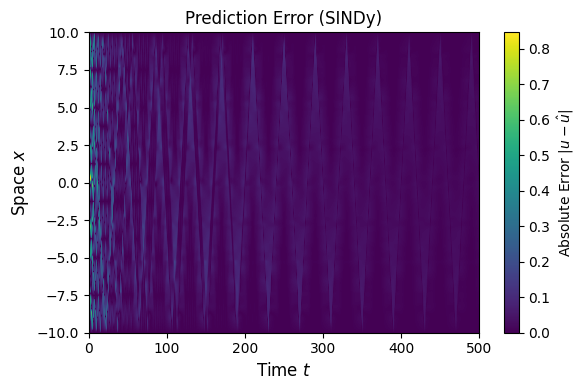

In [95]:
plt.figure(figsize=(6, 4))
plt.pcolormesh(t, x, np.abs(data[:, :, 0] - u_pred_full), shading='auto')
plt.colorbar(label='Absolute Error $|u - \hat{u}|$')
plt.xlabel('Time $t$', fontsize=12)
plt.ylabel('Space $x$', fontsize=12)
plt.title('Prediction Error (SINDy)')
plt.tight_layout()
plt.show()

Now add some noise

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:109: SyntaxWarning: invalid escape sequence '\h'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:109: SyntaxWarning: invalid escape sequence '\h'
/var/folders/7t/30q04zg93ml866ymrq48nkk80000gn/T/ipykernel_85641/3923309492.py:2: SyntaxWarning: invalid escape sequence '\s'
  df0 = pd.read_csv(r'/Users/lolovolkova/Desktop/pressure.txt', delimiter="\s+", index_col=False, header=None)
/var/folders/7t/30q04zg93ml866ymrq48nkk80000gn/T/ipykernel_85641/3923309492.py:3: SyntaxWarning: invalid escape sequence '\s'
  df1 = pd.read_csv(r'/Users/lolovolkova/Desktop/velocity.txt', delimiter="\s+", index_col=False, header=None)
/var/folders/7t/30q04zg93ml866ymrq48nkk80000gn/T/ipykernel_85641/3923309492.py:109: SyntaxWarning: invalid escape sequence '\h'
  plt.colorbar(label='Predicted Velocity $\hat{u}(x,t)$', orientation='horizontal', location='

SINDy MAE: 0.034248
Train time: 0.0096s, Predict time: 0.0015s


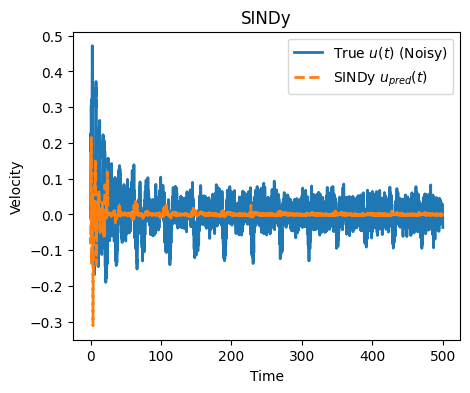

(x0)' = 7.984 1 + -7.342 x0 + -23.519 u0 + -6.374 x0^2 + 12.823 x0 u0 + 23.032 u0^2 + 4.386 x0^3 + 6.190 x0^2 u0 + -5.498 x0 u0^2 + -7.497 u0^3


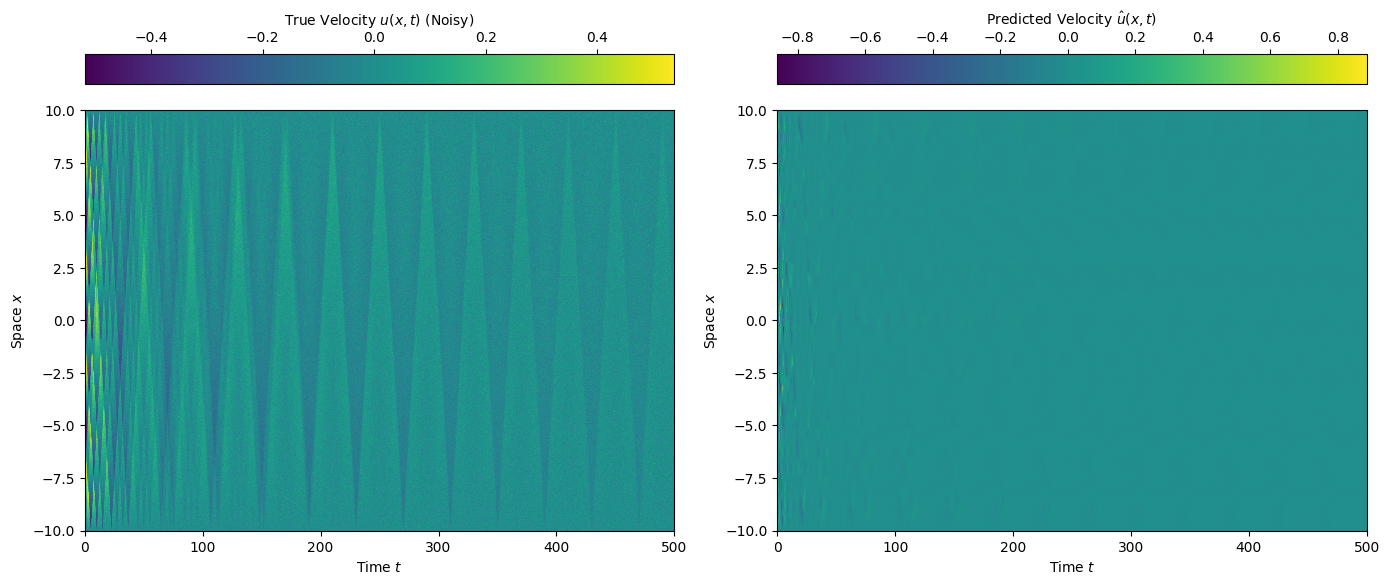

In [132]:
# Load data
df0 = pd.read_csv(r'/Users/lolovolkova/Desktop/pressure.txt', delimiter="\s+", index_col=False, header=None)
df1 = pd.read_csv(r'/Users/lolovolkova/Desktop/velocity.txt', delimiter="\s+", index_col=False, header=None)

# Extract x and raw data
x = df0.iloc[:, 0].to_numpy()
pressure = df0.drop(df0.columns[[0]], axis=1).to_numpy()
u = df1.drop(df1.columns[[0]], axis=1).to_numpy()

# Parameters
N = len(x)
totalNt = pressure.shape[1]
t = np.linspace(0, totalNt - 1, totalNt) / 10
Nt = len(t)
L = 20
T = t[-1]
dt = t[1] - t[0]

# Add Gaussian noise
noise_level = 0.5  # Adjust as needed
u_noisy = u + noise_level * np.std(u) * np.random.randn(*u.shape)
pressure_noisy = pressure + noise_level * np.std(pressure) * np.random.randn(*pressure.shape)

# Organize into data array
data = np.zeros((N, Nt, 2))
data[:, :, 0] = u_noisy
data[:, :, 1] = pressure_noisy

# Single spatial point for initial model
x_loc = 100
u_data = data[x_loc, :, 0].reshape(-1, 1)
p_data = data[x_loc, :, 1].reshape(-1, 1)

# Smooth and differentiate
u_smooth = savgol_filter(u_data.flatten(), window_length=51, polyorder=3)
du_dt = savgol_filter(u_data.flatten(), window_length=51, polyorder=3, deriv=1, delta=dt)
u_smooth = u_smooth.reshape(-1, 1)
du_dt = du_dt.reshape(-1, 1)

# Initialize and fit model
optimizer = ps.STLSQ(threshold=1e-10, alpha=1e-10, fit_intercept=False)
library = ps.PolynomialLibrary(degree=3, include_interaction=True, include_bias=True)
model = ps.SINDy(optimizer=optimizer, feature_library=library)

start = time.time()
model.fit(x=u_smooth, u=p_data, t=dt, x_dot=du_dt)
train_time = time.time() - start

# Predict and evaluate
start = time.time()
u_pred = model.predict(x=u_smooth, u=p_data)
pred_time = time.time() - start
mae = mean_absolute_error(u_data, u_pred)

print(f"SINDy MAE: {mae:.6f}")
print(f"Train time: {train_time:.4f}s, Predict time: {pred_time:.4f}s")

# Plot at single location
plt.figure(figsize=(5, 4))
plt.plot(t, u_data, label='True $u(t)$ (Noisy)', linewidth=2)
plt.plot(t, u_pred, '--', label='SINDy $u_{pred}(t)$', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Velocity')
plt.title(f'SINDy')
plt.legend()
plt.show()

model.print()

# Full field SINDy
u_pred_full = np.zeros((N, Nt))
train_times = []
pred_times = []

optimizer = ps.STLSQ(threshold=1e-10, alpha=1e-10, fit_intercept=False)
library = ps.PolynomialLibrary(degree=3, include_interaction=True)
model = ps.SINDy(optimizer=optimizer, feature_library=library, feature_names=["u", "p"])

for i in range(N):
    u_data = data[i, :, 0].reshape(-1, 1)
    p_data = data[i, :, 1].reshape(-1, 1)

    u_smooth = savgol_filter(u_data.flatten(), window_length=51, polyorder=3)
    du_dt = savgol_filter(u_data.flatten(), window_length=51, polyorder=3, deriv=1, delta=dt)
    u_smooth = u_smooth.reshape(-1, 1)
    du_dt = du_dt.reshape(-1, 1)

    start_train = time.time()
    model.fit(x=u_smooth, u=p_data, x_dot=du_dt, t=dt)
    train_times.append(time.time() - start_train)

    start_pred = time.time()
    u_pred = model.predict(x=u_smooth, u=p_data)
    pred_times.append(time.time() - start_pred)

    u_pred_full[i, :] = u_pred.flatten()

# Visualize
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.pcolormesh(t, x, data[:, :, 0], shading='auto')
plt.colorbar(label='True Velocity $u(x,t)$ (Noisy)', orientation='horizontal', location='top')
plt.xlabel('Time $t$')
plt.ylabel('Space $x$')

plt.subplot(1, 2, 2)
plt.pcolormesh(t, x, u_pred_full, shading='auto')
plt.colorbar(label='Predicted Velocity $\hat{u}(x,t)$', orientation='horizontal', location='top')
plt.xlabel('Time $t$')
plt.ylabel('Space $x$')

plt.tight_layout()
plt.show()

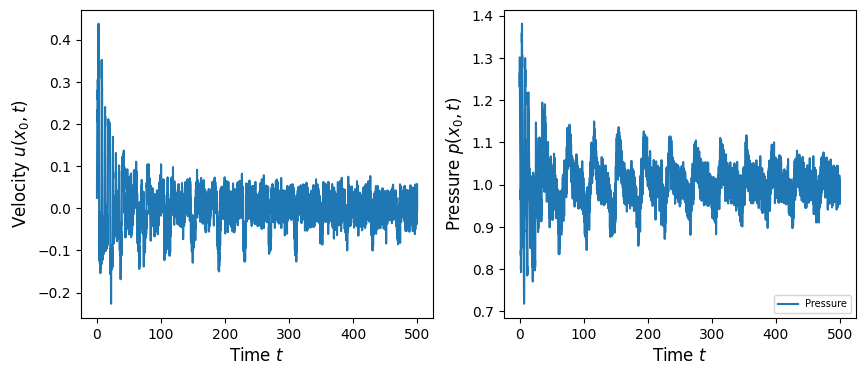

In [129]:
x_location = 100

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(t, data[x_location, :, 0],'-', color = 'C0', label='Velocity')
plt.xlabel('Time $t$', fontsize=12)
plt.ylabel('Velocity $u(x_0,t)$', fontsize=12)
#plt.legend(loc = 1, fontsize = 7)
#plt.title('u', fontsize=16)

plt.subplot(1, 2, 2)
plt.plot(t, data[x_location, :, 1],'-',color = 'C0',label='Pressure')
plt.xlabel('Time $t$', fontsize=12)
plt.ylabel(r'Pressure $p(x_0,t)$', fontsize=12)
plt.legend(loc = 4, fontsize = 7)
#plt.yticks(np.arange(0.9, 1.09, 0.05))
#plt.title(r'$\rho$', fontsize=16)

plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:88: SyntaxWarning: invalid escape sequence '\h'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:88: SyntaxWarning: invalid escape sequence '\h'
/var/folders/7t/30q04zg93ml866ymrq48nkk80000gn/T/ipykernel_85641/2761368460.py:10: SyntaxWarning: invalid escape sequence '\s'
  df0 = pd.read_csv(r'/Users/lolovolkova/Desktop/pressure.txt', delimiter="\s+", index_col=False, header=None)
/var/folders/7t/30q04zg93ml866ymrq48nkk80000gn/T/ipykernel_85641/2761368460.py:11: SyntaxWarning: invalid escape sequence '\s'
  df1 = pd.read_csv(r'/Users/lolovolkova/Desktop/velocity.txt', delimiter="\s+", index_col=False, header=None)
/var/folders/7t/30q04zg93ml866ymrq48nkk80000gn/T/ipykernel_85641/2761368460.py:88: SyntaxWarning: invalid escape sequence '\h'
  plt.colorbar(label='Predicted Velocity $\hat{u}(x,t)$', orientation='horizontal', locatio

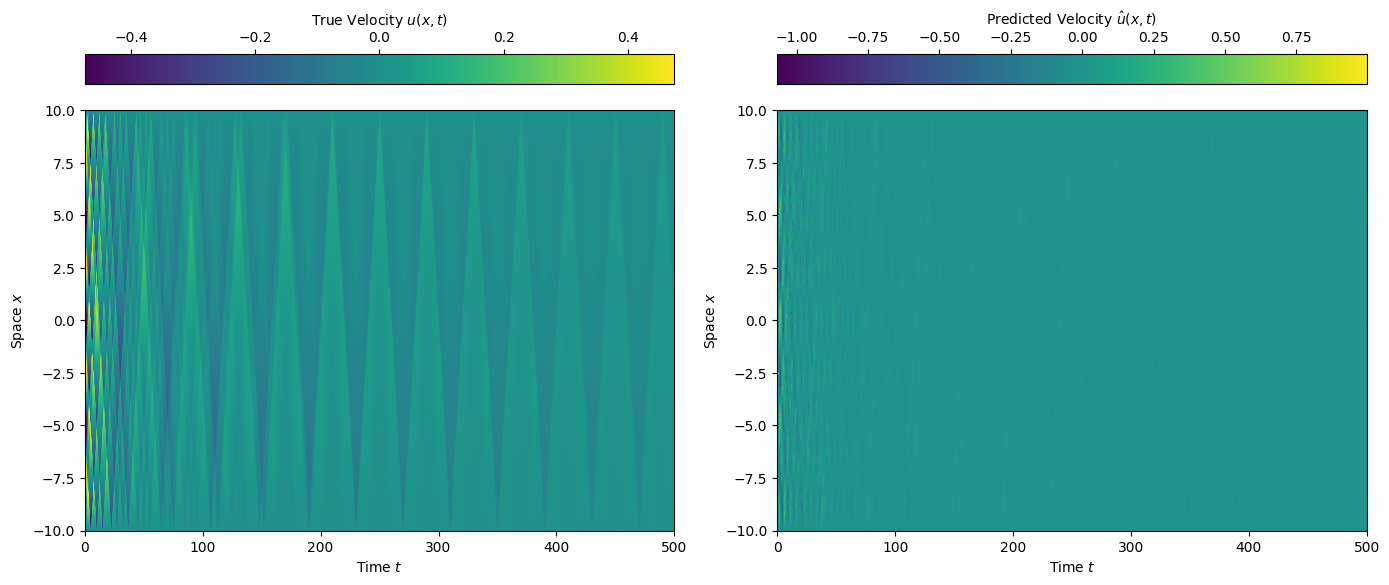

(u)' = 0.019 1 + 3.806 u + -0.044 p + 0.092 ux + -0.086 px + -628.857 u^2 + -2.440 u p + -25.611 u ux + -7.887 u px + 0.035 p^2 + -0.032 p ux + 0.172 p px + -0.049 ux^2 + 0.083 ux px + 0.315 px^2 + 1257.841 u^3 + 578.184 u^2 p + 460.329 u^2 ux + 155.178 u^2 px + -1.268 u p^2 + 24.278 u p ux + 14.404 u p px + 2.871 u ux^2 + -17.156 u ux px + -21.362 u px^2 + -0.011 p^3 + -0.058 p^2 ux + -0.087 p^2 px + 0.052 p ux^2 + 0.073 p ux px + -0.318 p px^2 + 0.005 ux^3 + 0.006 ux^2 px + -0.081 ux px^2 + 0.177 px^3


In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.metrics import mean_absolute_error
import pysindy as ps
import time

# Load data
df0 = pd.read_csv(r'/Users/lolovolkova/Desktop/pressure.txt', delimiter="\s+", index_col=False, header=None)
df1 = pd.read_csv(r'/Users/lolovolkova/Desktop/velocity.txt', delimiter="\s+", index_col=False, header=None)

# Extract spatial grid and time
x = df0.iloc[:, 0].to_numpy()
pressure = df0.drop(df0.columns[[0]], axis=1).to_numpy()
u = df1.drop(df1.columns[[0]], axis=1).to_numpy()
N = len(x)
Nt = pressure.shape[1]
t = np.linspace(0, Nt - 1, Nt) / 10
dt = t[1] - t[0]
dx = x[1] - x[0]  # Assumes uniform spacing

# Optional: add noise if desired
noise_level = 0.01
u += noise_level * np.std(u) * np.random.randn(*u.shape)
pressure += noise_level * np.std(pressure) * np.random.randn(*pressure.shape)

# Combine into data array
data = np.zeros((N, Nt, 2))
data[:, :, 0] = u
data[:, :, 1] = pressure

# Initialize results storage
u_pred_full = np.zeros((N, Nt))
train_times = []
pred_times = []

# Setup SINDy model
optimizer = ps.STLSQ(threshold=1e-5, alpha=1e-4, fit_intercept=False)
library = ps.PolynomialLibrary(degree=3, include_interaction=True)
model = ps.SINDy(optimizer=optimizer, feature_library=library, feature_names=["u", "p", "ux", "px"])

# Loop through all spatial points
for i in range(1, N - 1):  # avoid edges for central diff
    u_data = data[i, :, 0].reshape(-1, 1)
    p_data = data[i, :, 1].reshape(-1, 1)

    # Compute spatial derivatives (central differences)
    ux_data = (data[i + 1, :, 0] - data[i - 1, :, 0]) / (2 * dx)
    px_data = (data[i + 1, :, 1] - data[i - 1, :, 1]) / (2 * dx)

    # Time smoothing and time derivative
    u_smooth = savgol_filter(u_data.flatten(), window_length=51, polyorder=3)
    du_dt = savgol_filter(u_data.flatten(), window_length=51, polyorder=3, deriv=1, delta=dt)

    # Build feature matrix X
    X = np.hstack([
        u_smooth.reshape(-1, 1),
        p_data,
        ux_data.reshape(-1, 1),
        px_data.reshape(-1, 1)
    ])
    du_dt = du_dt.reshape(-1, 1)

    # Fit SINDy
    start_train = time.time()
    model.fit(x=X, x_dot=du_dt, t=dt)
    train_times.append(time.time() - start_train)

    # Predict
    start_pred = time.time()
    u_pred = model.predict(X)
    pred_times.append(time.time() - start_pred)

    u_pred_full[i, :] = u_pred.flatten()

# Visualize
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.pcolormesh(t, x, data[:, :, 0], shading='auto')
plt.colorbar(label='True Velocity $u(x,t)$', orientation='horizontal', location='top')
plt.xlabel('Time $t$')
plt.ylabel('Space $x$')

plt.subplot(1, 2, 2)
plt.pcolormesh(t, x, u_pred_full, shading='auto')
plt.colorbar(label='Predicted Velocity $\hat{u}(x,t)$', orientation='horizontal', location='top')
plt.xlabel('Time $t$')
plt.ylabel('Space $x$')

plt.tight_layout()
plt.show()

# Print discovered equation
model.print()


<>:10: SyntaxWarning: invalid escape sequence '\h'
<>:10: SyntaxWarning: invalid escape sequence '\h'
/var/folders/7t/30q04zg93ml866ymrq48nkk80000gn/T/ipykernel_85641/2460216867.py:10: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(t, u_pred, '--', label='SINDy $\hat{u}(t)$', linewidth=2)


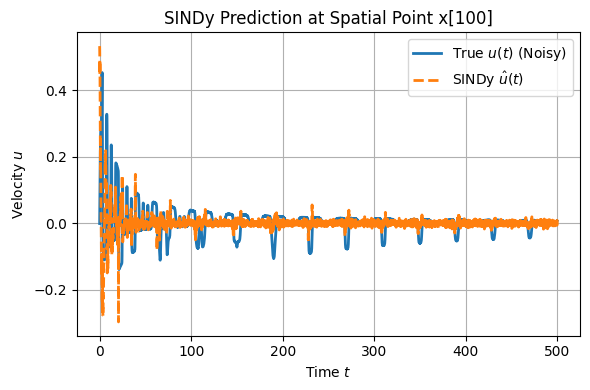

In [136]:
nx_loc = 100  # spatial index

# Extract data
u_data = data[x_loc, :, 0]          # True velocity (possibly noisy)
u_pred = u_pred_full[x_loc, :]      # SINDy predicted velocity

# Plot
plt.figure(figsize=(6, 4))
plt.plot(t, u_data, label='True $u(t)$ (Noisy)', linewidth=2)
plt.plot(t, u_pred, '--', label='SINDy $\hat{u}(t)$', linewidth=2)
plt.xlabel('Time $t$')
plt.ylabel('Velocity $u$')
plt.title(f'SINDy Prediction at Spatial Point x[{x_loc}]')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [138]:
# Flatten full velocity fields for comparison
u_true_flat = data[1:N-1, :, 0].flatten()
u_pred_flat = u_pred_full[1:N-1, :].flatten()

# Compute MAE
mae = mean_absolute_error(u_true_flat, u_pred_flat)

# Compute MAPE (avoid division by zero)
nonzero_mask = u_true_flat != 0
mape = np.mean(np.abs((u_true_flat[nonzero_mask] - u_pred_flat[nonzero_mask]) / u_true_flat[nonzero_mask])) * 100

error_time = time.time() - start_error

# Average times
avg_train_time = np.mean(train_times)
avg_pred_time = np.mean(pred_times)

# Print final results
print(f"\n===== SINDy Error Metrics =====")
print(f"SINDy MAE: {mae:.6f}")
print(f"SINDy MAPE: {mape:.3f}%")
print(f"Train time: {avg_train_time:.4f}s, Predict time: {avg_pred_time:.4f}s")
print(f"Error computation time: {error_time:.4f}s")



===== SINDy Error Metrics =====
SINDy MAE: 0.031751
SINDy MAPE: 691.328%
Train time: 0.0465s, Predict time: 0.0042s
Error computation time: 97.9779s
